<a href="https://colab.research.google.com/github/vanislekahuna/wps-labs/blob/main/Bayesian_Wildfire_Stats_Lab/Explaining_Markov_Chain_Monte_Carlo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Explaining Markov Chain Monte Carlo using Wildfire Forensics**

<img src="https://images.unsplash.com/photo-1692118457449-5241c79ea8d3?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" alt="Monaco" style="width:100%; max-width:1170px; height:auto; display:block; margin:0 auto;">

[Source](https://unsplash.com/photos/a-statue-of-a-man-holding-a-flag-on-top-of-a-building-liHTLDo7-08)

## Introduction

What does a statistician developing the physics behind the atomic bomb during WWII, a hacker cracking a 250-year-old cipher, or a data scientist fitting a Bayesian Linear Regression model actually have in common? On the surface, nothing. But underneath it is the same algorithm, one conceived by physicists at Los Alamos during the [Manhattan Project](https://www.astro.yale.edu/coppi/astro520/mcmc/0808.2902v4_mcmc_history.pdf) and further developed in the 1950s (Robert & Casella, 2011). Thankfully decades later, this algorithm was later used for entirely different, and less monstrous, applications such as cybersecurity engineers breaking substitution ciphers by testing which decoded candidates look most like real English. For statisticians or data scientists who’ve ever generated a posterior distribution using the world’s leading Pythonic programming framework called [PyMC](https://www.pymc.io/projects/docs/en/stable/api/generated/pymc.sample.html), then you've already used it without much thought to what's actually happening underneath.

The algorithm in question is the **Markov Chain Monte Carlo (MCMC)** which is a class of sampling algorithms used to generate a sample from a complex, multi-dimensional probability distribution (McElreath, 2020). With Bayesian models specifically, Markov Chain Monte Carlo generates a sampled approximation of the posterior distribution based on the priors distributions and likelihood/data we assign to a model. MCMC accomplishes this by constructing a “**Markov Chain**” that explores a target distribution, spending more time in areas of high probability, and uses random sampling (“**Monte Carlo**”) to estimate complex properties like approximating a multi-dimensional distribution to a single histogram. The Wikipedia flowchart in *Figure 1* illustrates how MCMC uses the Markov chain (middle) constrained by the prior distribution's range (left) to sample an approximation of the target posterior distribution (right).

<img src="https://upload.wikimedia.org/wikipedia/commons/d/de/Flowchart-of-Metropolis-Hastings-M-H-algorithm-for-the-parameter-estimation-using-the.png?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=thumbnail_unscaled" alt="Metropolis-Hastings" style="width:100%; max-width:850px; height:auto; display:block; margin:0 auto;">

[Source](https://en.wikipedia.org/wiki/Metropolis%E2%80%93Hastings_algorithm)

Given that MCMC is the central engine driving the application of Bayesian statistics to real-world applications, it’s vital for Bayesian practitioners to gain a strong intuition of the mechanism driving it - starting with its oldest and simplest variant, the **Metropolis algorithm**. Invented in 1953 by Metropolis, Rosenbluth, and Teller, this algorithm became the descendant of every modern MCMC sampler today. Given its importance to the field of Bayesian Inference and Statistical Machine Learning overall, we wrote this article to delve deeper into how it works from a conceptual level. But rather than working through the idea in an abstract manner, we’ll approach it from a unique story angle: By investigating the ignition source of a wildfire with our resident forensic ecologist, Prof Markov, who will meet the challenge with nothing more than a burn map, some historical fire-risk records, and an eight-sided die. Let’s hop into Markov’s world:

## Professor Markov's Investigation

<img src="https://images.unsplash.com/photo-1536245344390-dbf1df63c30a?q=80&w=1173&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" alt="Burnt-Forest" style="width:100%; max-width:1170px; height:auto; display:block; margin:0 auto;">

[Source](https://unsplash.com/photos/silhouette-of-trees-on-smoke-covered-forest-S9NQnIV4zOI)

Prof. Markov is a wildfire forensic ecologist assigned to investigate a remote section of a forest in Monaco that burned overnight (though in reality, Monaco is a city state that doesn’t have its own forest 😅). By morning, helicopters have marked the burn scar which are identified as the cells that are completely black on a 5x5 grid map (25 total cells), along with the cells that are untouched and green. The pattern of char intensity and fire spread direction leaves a forensic signature pointing toward where the fire originated.

Prof. Markov’s job is to estimate the location of the **ignition source** of the fire  which won’t be an easy task. The terrain is rugged, some areas are still smoldering, and even the best forensic evidence leaves genuine ambiguity because wind shifts and overlapping fuel beds prevent the true ignition location from being known with certainty. Essentially, a single point estimate (i.e. “the fire started here”) in this case would be scientifically dishonest. What he needs is a **probability distribution over the entire grid** which would quantify which cells are potential ignition sources and how plausible is each one relative to the others.

Given the task, Prof. Markov has two sources of information.

1. The first is a prior which are historical records that describe which cells/areas carry a higher baseline ignition risk. These historical records quantify risk based on factors such as the proximity to logging roads, known campfire sites, or dry lightning strike frequency.

2. The second source of information is a likelihood which is the burn pattern of the fire itself. Cells that sit at the upwind origin of the spread, surrounded by the most intense char, and with fire vectors radiating outward, score higher as candidate ignition sources.

In [ ]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pymc as pm
import warnings

from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from scipy.stats import multivariate_normal
from scipy.ndimage import gaussian_filter

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.set_option("mode.chained_assignment", None)

In [ ]:
%config Inline.figure_format = 'retina'
az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89  # sets default credible interval used by arviz

For each of the 25 cells in the grid similar to what we have in *Figure 2*, Prof. Markov computes the unnormalised posterior by simply multiplying the prior ignition risk of that cell by the likelihood score given the observed burn pattern. The math here isn't important. The key point is that through this process, Prof Markov was able to generate a grid of 25 "posterior" burn scar values where higher values indicate more plausible ignition sources. Note that these values don’t need to sum to 1 since they’re supposed to be unnormalised. Therefore, Markov’s posterior represents the thing that he actually wants which combines both the prior and the likelihood:

$$P(\text{ignition at cell } x \mid \text{burn pattern}) \propto P(\text{ignition at } x) \times P(\text{burn pattern} \mid \text{ignition at } x) $$

Which is essentially **Bayes' Theorem** at its core:

$$P(\text{H} \mid \text{E}) \propto \frac{P(\text{Hypothesis}) \times P(\text{Evidence} \mid \text{Hypothesis})}{P(\text{Evidence})}$$

To turn our posterior, $P( H \mid E)$, into a proper probability distribution, Markov would need to compute the total probability mass across every cell in the grid, summing the right-hand side over all 25 cells, then dividing by that sum. However in the real world where there can be millions of candidate ignition points, doing this math is completely impractical as he would never be able to write it down, let alone compute it. The method we're describing here is the grid approximation method which is intuitive but very computationally expensive and unfeasible with high parameter models or large datasets. Luckily, there's smarter ways to solve this problem of sampling from the posterior which works in the following way:

## The **Markov Chain Monte Carlo** algorithm

Prof. Markov moves through the grid one cell at a time each day, collecting forensic evidence as he goes. Each day he follows these three rules  which, in reality, are the <u>theoretical foundations of the **Markov Chain Monte Carlo** algorithm</u>:

> **1. Proposal Step**: Roll an eight-sided die (i.e. an octahedron dice) to propose a move in one of the following directions: 1 = North, 2 = Northeast, 3 = East, 4 = Southeast, 5 = South, 6 = Southwest, 7 = West, or 8 = Northwest. If the roll would take him outside the grid, re-roll until it doesn't.
>
> **2. Acceptance Ratio**: Evaluate the posterior probability of the proposed cell ($p_{\text{move}}$) relative to his current position:
> $$p_{\text{move}} = \frac{P(\text{ignition at proposed cell} \mid \text{burn pattern})}{P(\text{ignition at current position} \mid \text{burn pattern})}$$
>
> **3. Accept/Reject Step**: If $p_{\text{move}} \geq 1$, that means the proposed cell is more probable than the current one so he should move there with certainty. If $p_{\text{move}} < 1$, this means that the proposed cell is less probable than the current one. In this case, Prof. Markov then needs to draw a random number ($u$) from a uniform random number generator between 0 and 1.
>  - If $u < p_{\text{move}}$, then he can move to the proposed cell. But if $u \geq p_{\text{move}}$, then he needs to stay put. The lower the ratio of $p_{\text{move}}$, the more likely the draw fails which therefore means he must stay put.

## Visualizing the Metropolis-variant of MCMC

With Python code, let's examine how this algorithm works when Prof. Markov works by sampling 10 days worth of movement (`num_days = 10`) across the cells in our grid:

In [ ]:
#######################################
### Metropolis-variant MCMC Sampler ###
#######################################
example_posterior_dist = np.array([
    [1.2,  2.1,  3.4,  2.8,  1.5],
    [1.8,  4.2,  7.1,  5.3,  2.3],
    [2.5,  6.8, 10.0,  8.4,  3.7],
    [1.9,  5.1,  8.6,  6.9,  4.2],
    [1.1,  2.7,  4.3,  3.5,  2.0],
])

D8_MOVES = [
    (-1,  0),   # North
    (-1, +1),   # Northeast
    ( 0, +1),   # East
    (+1, +1),   # Southeast
    (+1,  0),   # South
    (+1, -1),   # Southwest
    ( 0, -1),   # West
    (-1, -1),   # Northwest
]

D8_NAMES = ["North", "Northeast", "East", "Southeast", "South", "Southwest", "West", "Northwest"]

num_days = 10
positions = []
current = (0, 0) # start at top-left corner of the grid

for day in range(num_days):
    # record current position
    positions.append(current)

    # Rule 1 — Roll D8 and re-roll if outside the grid
    # roll D8 to generate proposal
    roll = np.random.randint(8)
    dr, dc = D8_MOVES[roll]
    direction = D8_NAMES[roll]

    proposal = (current[0] + dr, current[1] + dc)

    # re-roll if proposal falls outside the grid
    while not (0 <= proposal[0] < 5 and 0 <= proposal[1] < 5):
      roll = np.random.randint(8)
      dr, dc = D8_MOVES[roll]
      direction = D8_NAMES[roll]

      proposal = (current[0] + dr, current[1] + dc)

    print(f"\nDay {day + 1}")
    print(f"Current position: {current}  (posterior = {example_posterior_dist[current]:.1f})")
    print(f"[Rule 1] Rolled: {direction} → proposed {proposal}  (posterior = {example_posterior_dist[proposal]:.1f})")


    # Rule 2 — Compute the acceptance ratio:
    # move?
    prob_move = example_posterior_dist[proposal] / example_posterior_dist[current]
    print(f"[Rule 2] Acceptance ratio : {example_posterior_dist[proposal]:.3f} / {example_posterior_dist[current]:.3f} = {prob_move:.3f}")


    # Rule 3 — Move or stay put:
    # this will always be >1 (outside of np.random.uniform()) if proposal is greater
    if prob_move >= 1:
        current = proposal
        print(f"[Rule 3] Decision: p_move >= 1 — moved to {current} without hesitation")
    else:
        u = np.random.uniform()
        if u < prob_move:
            current = proposal
            print(f"Decision: p_move < 1 — drew u = {u:.3f} < {prob_move:.3f} — moved to {current}")
        else:
            print(f"Decision: p_move < 1 — drew u = {u:.3f} >= {prob_move:.3f} — staying put at {current}")


Day 1
Current position: (0, 0)  (posterior = 1.2)
[Rule 1] Rolled: South → proposed (1, 0)  (posterior = 1.8)
[Rule 2] Acceptance ratio : 1.800 / 1.200 = 1.500
[Rule 3] Decision: p_move >= 1 — moved to (1, 0) without hesitation

Day 2
Current position: (1, 0)  (posterior = 1.8)
[Rule 1] Rolled: Southeast → proposed (2, 1)  (posterior = 6.8)
[Rule 2] Acceptance ratio : 6.800 / 1.800 = 3.778
[Rule 3] Decision: p_move >= 1 — moved to (2, 1) without hesitation

Day 3
Current position: (2, 1)  (posterior = 6.8)
[Rule 1] Rolled: East → proposed (2, 2)  (posterior = 10.0)
[Rule 2] Acceptance ratio : 10.000 / 6.800 = 1.471
[Rule 3] Decision: p_move >= 1 — moved to (2, 2) without hesitation

Day 4
Current position: (2, 2)  (posterior = 10.0)
[Rule 1] Rolled: Southeast → proposed (3, 3)  (posterior = 6.9)
[Rule 2] Acceptance ratio : 6.900 / 10.000 = 0.690
Decision: p_move < 1 — drew u = 0.746 >= 0.690 — staying put at (2, 2)

Day 5
Current position: (2, 2)  (posterior = 10.0)
[Rule 1] Rolled: S

In [ ]:
rng = np.random.default_rng(137)

TRUE_IGNITION = (1, 2)

cell_names = [
    ["Ridge Plateau",  "North Slope",   "Summit Meadow", "East Bluff",    "Far Ridge"],
    ["West Treeline",  "Mixed Forest",  "Dry Gulch",     "Open Stand",    "Rocky Bench"],
    ["River Terrace",  "Dense Spruce",  "South Meadow",  "Burn Scar Ctr", "Creek Bend"],
    ["Valley Floor",   "Alder Thicket", "Logging Road",  "Slash Pile",    "Dry Grass SE"],
    ["Wetland Fringe", "Bog Edge",      "Road Junction", "Campsite",      "Meadow Edge"],
]

# PRIOR
prior_raw = np.array([
    [0.6, 0.7, 1.8, 0.6, 0.4],
    [0.5, 0.8, 1.2, 0.7, 0.4],
    [0.5, 0.6, 0.9, 0.6, 0.5],
    [0.6, 0.7, 2.5, 1.1, 0.8],
    [0.4, 0.4, 1.6, 2.8, 0.6],
], dtype=float)
prior_raw = gaussian_filter(prior_raw, sigma=0.6)
prior = prior_raw / prior_raw.sum()

# BURN PATTERN
WIND_DR = np.array([-0.3, 0.6])
char_intensity = np.zeros((5, 5))
for r in range(5):
    for c in range(5):
        vec = np.array([r - TRUE_IGNITION[0], c - TRUE_IGNITION[1]], dtype=float)
        dist = np.linalg.norm(vec) + 1e-6
        wind_align = np.dot(vec, WIND_DR) / dist
        char_intensity[r, c] = np.exp(-0.55 * dist) * (1.0 + 0.5 * wind_align)
char_intensity = np.clip(char_intensity, 0.01, None)
BURN_THRESHOLD = 0.28
burnt = char_intensity > BURN_THRESHOLD

# LIKELIHOOD
burnt_coords = np.argwhere(burnt)
centroid = burnt_coords.mean(axis=0)

likelihood_raw = np.zeros((5, 5))
for r in range(5):
    for c in range(5):
        dist_centroid = np.linalg.norm(np.array([r, c]) - centroid)
        centroid_score = np.exp(-0.7 * dist_centroid)
        vec_from_cent = np.array([r - centroid[0], c - centroid[1]])
        upwind_score = np.exp(-1.2 * np.dot(vec_from_cent, WIND_DR))
        char_score = char_intensity[r, c] ** 0.5
        burnable_penalty = 0.5 if r == 4 and c in [0, 1] else 1.0
        likelihood_raw[r, c] = centroid_score * upwind_score * char_score * burnable_penalty

likelihood_raw = gaussian_filter(likelihood_raw, sigma=0.5)
likelihood_raw = np.clip(likelihood_raw, 1e-4, None)
# likelihood = likelihood_raw / likelihood_raw.sum()

# POSTERIOR
posterior_unnorm = likelihood_raw * prior_raw
posterior = posterior_unnorm / posterior_unnorm.sum()

# SAMPLER
D8_MOVES = [(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1),(-1,-1)]
num_days = int(100000)
board_positions = []
current = (4, 4)
accepted = 0
trace_full = []

for day in range(num_days):
    board_positions.append(current)
    trace_full.append(current)
    roll = rng.integers(0, 8)
    dr, dc = D8_MOVES[roll]
    nr, nc = current[0] + dr, current[1] + dc
    attempts = 0
    while not (0 <= nr < 5 and 0 <= nc < 5):
        roll = rng.integers(0, 8)
        dr, dc = D8_MOVES[roll]
        nr, nc = current[0] + dr, current[1] + dc
        attempts += 1
        if attempts > 50:
            nr, nc = current
            break
    proposed = (nr, nc)
    prob_move = posterior_unnorm[proposed] / posterior_unnorm[current]
    if rng.random() < min(1.0, prob_move):
        current = proposed
        accepted += 1

board_positions = np.array(board_positions)
visit_counts = np.zeros((5, 5), dtype=int)
np.add.at(visit_counts, (board_positions[:, 0], board_positions[:, 1]), 1)
# for r, c in board_positions:
#     visit_counts[r, c] += 1
visit_freq = visit_counts / visit_counts.sum()
max_err = np.abs(visit_freq - posterior).max()
accept_rate = accepted / num_days

print(f"True ignition   : {TRUE_IGNITION}")
print(f"MAP estimate    : {np.unravel_index(visit_freq.argmax(),(5,5))}")
print(f"Acceptance rate : {accept_rate:.1%}")
print(f"Max cell error  : {max_err:.4f}")

# COLOURS
BG = "#0d1117"
PANEL_BG = "#161b22"
TEXT = "#e6edf3"
SUBTEXT = "#8b949e"
ACCENT = "#f78166"
ACCENT2 = "#79c0ff"
GREEN = "#56d364"
WARM = "#e3b341"
GRID_C = "#30363d"

forest_green = LinearSegmentedColormap.from_list("fg",   ["#0d2b0d","#1a5c1a","#2d8a2d","#56d364","#c8ffc8"], N=256)
ember_cmap = LinearSegmentedColormap.from_list("ember",["#161b22","#3d1a00","#8b3a00","#e3b341","#f78166","#ffddcc"], N=256)
posterior_cmap = LinearSegmentedColormap.from_list("post", ["#0d1117","#1a2a4a","#1f4f8a","#2196f3","#e3b341","#f78166"], N=256)
burn_cmap  = LinearSegmentedColormap.from_list("burn", ["#1a5c1a","#56d364","#1a1a1a","#8b3a00","#e3b341","#f78166"], N=512)


def style_grid(ax, title, subtitle=""):
    t = title if not subtitle else f"{title}\n{subtitle}"
    ax.set_title(t, color=TEXT, fontsize=12, fontweight="bold", pad=9, loc="left", linespacing=1.5)
    ax.set_xticks(np.arange(5)); ax.set_yticks(np.arange(5))
    ax.set_xticklabels([f"C{i+1}" for i in range(5)], color=SUBTEXT, fontsize=8.5)
    ax.set_yticklabels([f"R{i+1}" for i in range(5)], color=SUBTEXT, fontsize=8.5)
    ax.tick_params(length=0)
    for x in np.arange(-0.5, 5, 1):
        ax.axhline(x, color=GRID_C, lw=0.8)
        ax.axvline(x, color=GRID_C, lw=0.8)

def add_cb(fig, ax, im, label=""):
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cb.ax.yaxis.set_tick_params(color=SUBTEXT, labelcolor=SUBTEXT, labelsize=8)
    cb.outline.set_edgecolor(GRID_C)
    if label: cb.set_label(label, color=SUBTEXT, fontsize=8)

True ignition   : (1, 2)
MAP estimate    : (np.int64(1), np.int64(2))
Acceptance rate : 69.8%
Max cell error  : 0.0237


And for reference, *Figure 2* represents the "true" posterior distribution of the burnt Monaco forest from which we'll use to compare our sampled posterior against later on.

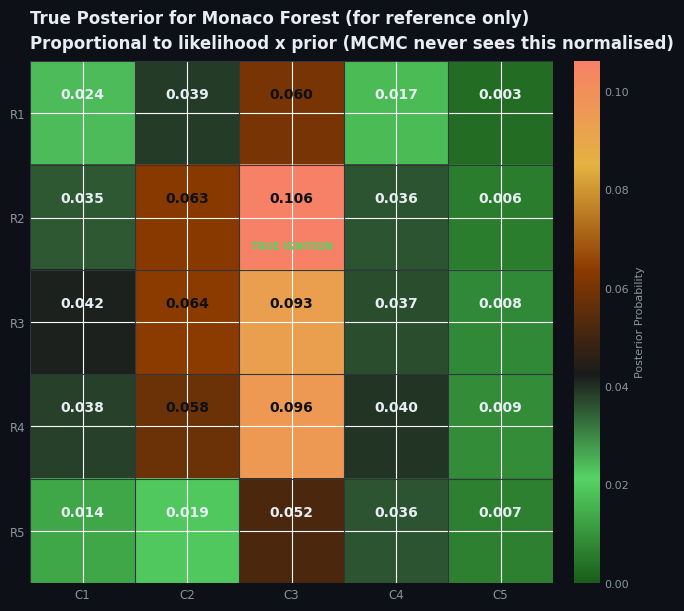

In [ ]:
fig_burn, ax_burn = plt.subplots(figsize=(8, 6), facecolor=BG)
ax_burn.set_facecolor(PANEL_BG)
for sp in ax_burn.spines.values():
    sp.set_color(GRID_C)

# True posterior
im_post = ax_burn.imshow(posterior, cmap=burn_cmap, aspect="equal", vmin=0) #posterior_cmap
style_grid(ax_burn, "True Posterior for Monaco Forest (for reference only)",
           "Proportional to likelihood x prior (MCMC never sees this normalised)")

for r in range(5):
    for c in range(5):
        v = posterior[r, c]
        col = "#0d1117" if v > posterior.max()*0.5 else TEXT
        ax_burn.text(c, r-0.18, f"{v:.3f}", ha="center", va="center", fontsize=10, fontweight="bold", color=col)
        if (r,c) == TRUE_IGNITION:
            ax_burn.text(c, r+0.28, "TRUE IGNITION", ha="center", va="center", fontsize=7, color=GREEN, fontweight="bold")
add_cb(fig_burn, ax_burn, im_post, "Posterior Probability")

After enough days of traversing the grid this way, we'll find that the proportion of time Prof. Markov spends in each cell converges to that cell's true posterior probability. He'll visit high-probability ignition cells more often and low-probability cells less often, not because he was told their probabilities in advance, but because the accept/reject rule steers him there naturally over time. *Figure 3* shows his path across the first 100 steps, starting in the sparse bottom-right corner and gradually drifting toward the high-posterior central cells.

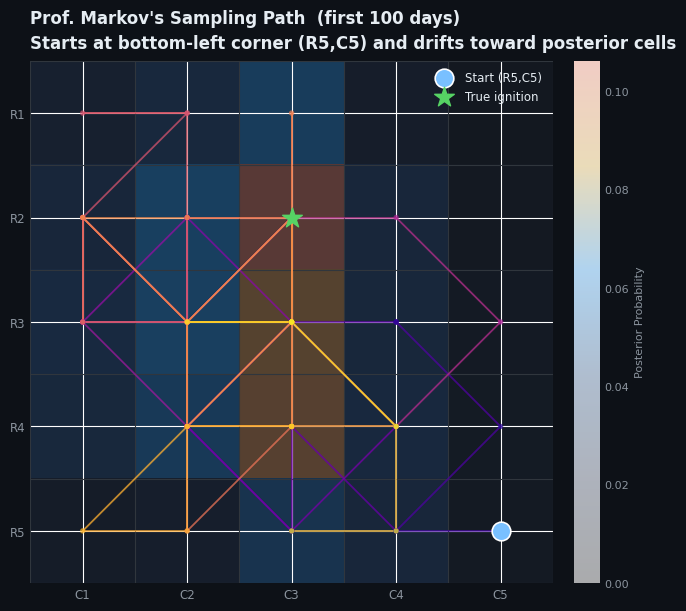

In [ ]:
fig_path, ax_path = plt.subplots(figsize=(8, 6), facecolor=BG)
ax_path.set_facecolor(PANEL_BG)
for sp in ax_path.spines.values():
    sp.set_color(GRID_C)

TRACE_LEN = 100
im_show = ax_path.imshow(posterior, cmap=posterior_cmap, aspect="equal", vmin=0, alpha=0.3)
style_grid(ax_path, f"Prof. Markov's Sampling Path  (first {TRACE_LEN} days)",
           "Starts at bottom-left corner (R5,C5) and drifts toward posterior cells")
colors_path = plt.cm.plasma(np.linspace(0.1, 0.95, TRACE_LEN))

for k in range(TRACE_LEN-1):
    r0,c0 = trace_full[k]; r1,c1 = trace_full[k+1]
    ax_path.plot([c0,c1],[r0,r1], color=colors_path[k], lw=1.3, alpha=0.75)

rs = [p[0] for p in trace_full[:TRACE_LEN]]
cs_p = [p[1] for p in trace_full[:TRACE_LEN]]
ax_path.scatter(cs_p, rs, c=range(TRACE_LEN), cmap="plasma", s=15, zorder=4, alpha=0.7, linewidths=0, vmin=0, vmax=TRACE_LEN)
ax_path.scatter([trace_full[0][1]], [trace_full[0][0]], color=ACCENT2, s=180, zorder=7, marker="o", edgecolors="white", linewidths=1.2, label="Start (R5,C5)")
ax_path.scatter([TRUE_IGNITION[1]], [TRUE_IGNITION[0]], color=GREEN, s=220, zorder=7, marker="*", label="True ignition")
ax_path.legend(facecolor=PANEL_BG, edgecolor=GRID_C, labelcolor=TEXT, fontsize=8.5, loc="upper right")

add_cb(fig_path, ax_path, im_show, "Posterior Probability")

*Figure 4* titled "**Sampled Posterior Distribution Heatmap**" is the result we want as it shows visit frequencies after 100,000 steps where the Metropolis-variant of MCMC has tightly recovered the true posterior distribution across all 25 cells. One thing to note about this graph is that it is essentially equivalent to the one-dimensional posterior distribution histogram that we typically generate whenever we build a Bayesian model. The reason why we don't have that same histogram where we typically use the `ax.plot_density()` function to generate is because in our case, each cell that we sampled is a two-dimensional object. Although we can, in theory, "flatten" the X and Y coordinates in order to build a histogram that counted up how much each cell was sampled, it wouldn't be as effective of a visualization due to the categorical nature of the cells which is why a **heatmap** for this graph made more sense in this situation. In structuring our example this way, we're then able to emphasize the idea that a posterior doesn't have to be just a bell curve on a histogram. *A **posterior distribution** can also be a 25-element probability mass function spread across a spatial grid.*

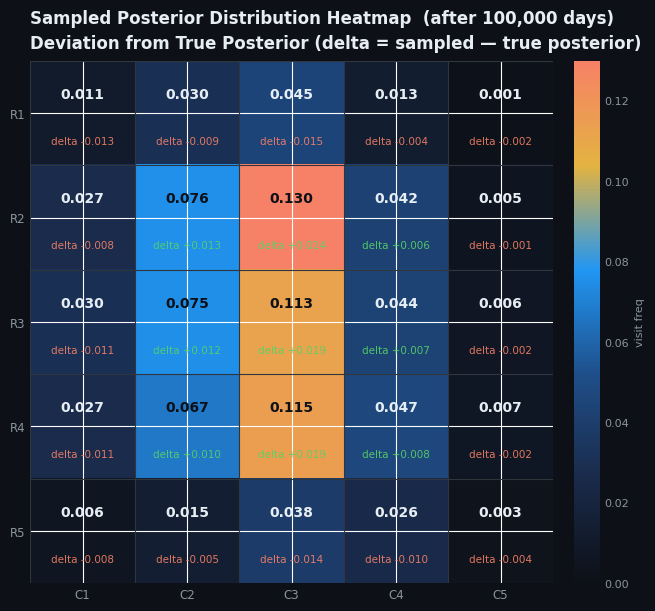

In [ ]:
fig_visits, ax_visits = plt.subplots(figsize=(8, 6), facecolor=BG)
ax_visits.set_facecolor(PANEL_BG)
for sp in ax_visits.spines.values():
    sp.set_color(GRID_C)

im_vis = ax_visits.imshow(visit_freq, cmap=posterior_cmap, aspect="equal", vmin=0)
style_grid(ax_visits, f"Sampled Posterior Distribution Heatmap  (after {num_days:,} days)",
           "Deviation from True Posterior (delta = sampled — true posterior)")
for r in range(5):
    for c in range(5):
        v = visit_freq[r,c]
        err = v - posterior[r,c]
        col = "#0d1117" if v > visit_freq.max()*0.5 else TEXT
        ax_visits.text(c, r-0.18, f"{v:.3f}", ha="center", va="center", fontsize=10, fontweight="bold", color=col)
        ecol = GREEN if err >= 0 else ACCENT
        ax_visits.text(c, r+0.27, f"delta {err:+.3f}", ha="center", va="center", fontsize=7.5, color=ecol, alpha=0.9)
add_cb(fig_visits, ax_visits, im_vis, "visit freq")

Lastly, *Figure 5* is a **convergence plot** showing how the sampled visit frequency of the true ignition cell (i.e. cell `R2C3`) evolves as the number of simulated days increases on a log scale, gradually stabilizing around the true posterior probability of 0.106 as more samples accumulate. To re-iterate, Markov doesn't just want to know which single cell is most likely as that would be a point estimate which is no better than a guess. He wants to know:

A) The full distribution which represents how confident he can be in the top candidate of the ignition source;

B) How much probability mass sits in the neighbouring cells;

C) And which regions of the grid can be ruled out entirely.

The record of positions he accumulated over 100,000 days *is* that distribution. Every quantity of the forensic analysis, from the probability that the ignition source was within 100 metres of the logging road, to the 89% credible region of candidate cells, or the expected char intensity at the true ignition point, can be estimated simply by averaging over that record.

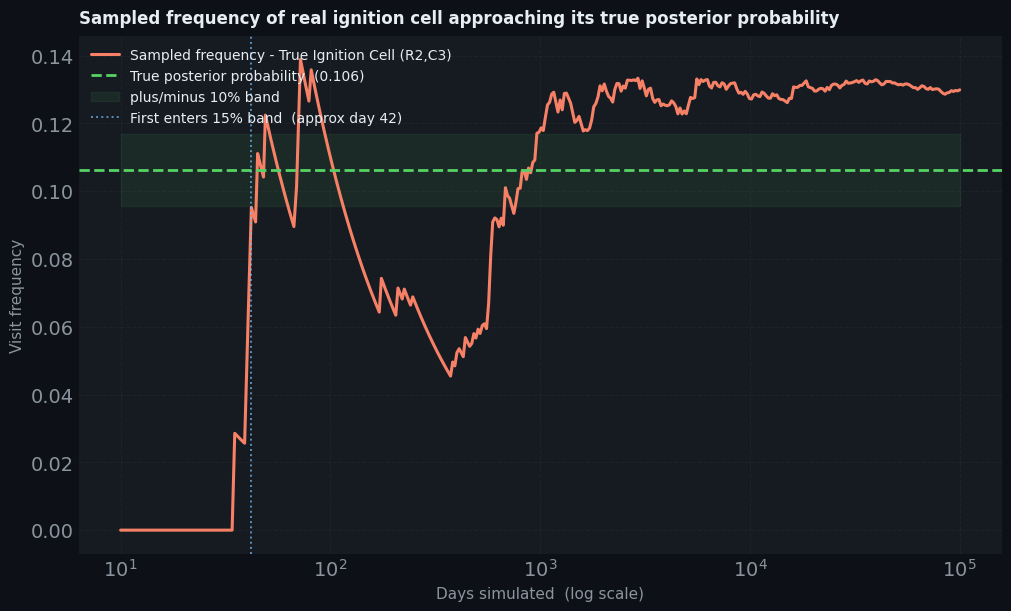

In [ ]:
fig_conv, ax_conv = plt.subplots(figsize=(10, 6), facecolor=BG)
ax_conv.set_facecolor(PANEL_BG)
for sp in ax_conv.spines.values():
    sp.set_color(GRID_C)

checkpoints = np.unique(np.logspace(1, np.log10(num_days), 400).astype(int))
target_cell = TRUE_IGNITION
target_val  = posterior[target_cell]

is_target = (board_positions[:, 0] == target_cell[0]) & (board_positions[:, 1] == target_cell[1])
cumulative_hits = np.cumsum(is_target)
cumul_freq = cumulative_hits[checkpoints - 1] / checkpoints

ax_conv.plot(checkpoints, cumul_freq, color=ACCENT, lw=2.2, label=f"Sampled frequency - True Ignition Cell (R{TRUE_IGNITION[0]+1},C{TRUE_IGNITION[1]+1})")
ax_conv.axhline(target_val, color=GREEN, lw=2.0, ls="--", label=f"True posterior probability  ({target_val:.3f})")
ax_conv.fill_between(checkpoints, target_val*0.9, target_val*1.1, color=GREEN, alpha=0.08, label="plus/minus 10% band")

burnin_arr = np.abs(cumul_freq - target_val)
burnin_idx = np.argmax(burnin_arr < target_val*0.15)

if burnin_idx > 0:
    ax_conv.axvline(checkpoints[burnin_idx], color=ACCENT2, lw=1.4, ls=":", alpha=0.7, label=f"First enters 15% band  (approx day {checkpoints[burnin_idx]:,})")

ax_conv.set_xscale("log")
ax_conv.set_xlabel("Days simulated  (log scale)", color=SUBTEXT, fontsize=11)
ax_conv.set_ylabel("Visit frequency", color=SUBTEXT, fontsize=11)
ax_conv.set_title("Sampled frequency of real ignition cell approaching its true posterior probability", color=TEXT, fontsize=12, fontweight="bold", pad=9, loc="left")
ax_conv.tick_params(colors=SUBTEXT)
ax_conv.yaxis.grid(True, ls="--", alpha=0.2, color="#444")
ax_conv.xaxis.grid(True, ls="--", alpha=0.2, color="#444")

ax_conv.legend(facecolor=PANEL_BG, edgecolor=GRID_C, labelcolor=TEXT, fontsize=10, loc="upper left")

And this, ladies and gentlemen, is the **Metropolis**-flavour of the oldest and simplest member of the MCMC family. Its power comes from one profound property: That it works in spaces where exhaustive enumeration is impossible. But over a real continuous landscape, the number of candidate ignition points is infinite. There is no grid to sum over, no list of cells to evaluate. However, the algorithm doesn't need a list. It only ever asks one question at a time: *Is where I might go more or less probable than where I am right now?* That local comparison, repeated thousands of times, is enough to map out the entire posterior distribution.

## Limitations

While the Metropolis algorithm is a great way to learn the basics of MCMC, it does struggle with some glaring weaknesses that have since left it outclassed by more modern variants, such as the Hamiltonian Monte Carlo algorithm. One weakness is that although we mentioned how MCMC is generally capable of sampling from high-dimensional models, the early Metropolis variant runs into a scaling wall when dealing with models with hundreds, or thousands, of parameters. The reason for this is in part because Metropolis doesn’t have any mechanisms to learn a posterior’s overall shape which is a necessity when dealing with high-parameter models. Without having a lay of the land, Metropolis struggles to cope with a geometric property of high-dimensional distributions known as **concentration of measure** where most of a posterior's probability mass lives in a thin, curved shell far from its peak. Because Metropolis can only sample a few dimensions at a time, it isn't capable of navigating that shell efficiently, or quickly for that matter.

Another issue with Metropolis’ ability to effectively traverse through the sampling space has to do with the issue of **autocorrelation**. Because proposals are generated blindly, with no sense of the posterior's shape, the algorithm naturally tends to sample from neighbouring regions with similar probability. The autocorrelational issues are then further compounded when two or more parameters are highly correlated. Forcing the algorithm to take larger step sizes (i.e. travel larger distances as opposed to our example with Prof Markov who only hopped to neighbouring cells) may help increase the diversity of the sampling space but at the cost of reducing the acceptance rate as it samples from lower-probability areas more often.

One more inherent weakness with Metropolis is due to its proposal mechanism being *symmetrical* which means that it assumes that every proposed step (or direction) is just as likely as the other options available. In practice however, this characteristic does not hold up because plenty of parameters have natural constraints that make symmetric proposals inappropriate, such as with standard deviations where the values must be strictly positive. Years later, Professor W.K. Hastings (1970) made the algorithm more generalizable by adding a **correction factor, $q$,** to the acceptance ratio, where $q(\text{proposed} \mid \text{current})$ is the probability of proposing the new point from the current one, to account for these (unequal) *asymmetric proposals*. As a result of Hastings’ contributions in expanding the original algorithm to a vastly broader class of problems, it’s actually now more widely known as the **Metropolis-Hastings algorithm** in the academic statistics or CS community. What’s funny though is that its impact wasn’t truly felt until about two decades later when we began to see the explosion of computational methods.

$$p_{\text{move}} = \min\left(1, \frac{P(\text{proposed}) \cdot q(\text{current} \mid \text{proposed})}{P(\text{current}) \cdot q(\text{proposed} \mid \text{current})}\right) $$

Going back to our sampling example in the burnt forest, an example of this would be where Prof. Markov’s octahedron was loaded so that it lands on Southeast twice as often as any other direction. A manufacturing error caused “Southeast” to appear twice with one of them replacing where “East” would have been on the die. Now we can say the proposal is asymmetric since the probability of proposing a move from a corner cell toward the centre (i.e. moving Southeast from cell `R1C1` to `R2C2`) is higher than the probability of proposing the reverse move from the centre back out to the corner (i.e. moving Northwest from cell `R2C2` back to` R1C1`). Without a correction, this bias would cause Prof. Markov to over-visit central cells not because the posterior says he should, but simply because the die keeps pushing him there. The acceptance ratio would no longer reflect purely the posterior because it would be contaminated by the geometry of the die. The Metropolis-Hastings correction factor $q$ fixes this exactly. If the loaded die proposes Southeast with a probability of $\frac{2}{8}$ but moving South only has a probability of $\frac{1}{8}$, then moving from a corner cell at position $A$ to a central cell at position $B$ requires dividing by $q(B \mid A) = \frac{1}{8}$ by $q(A \mid B) = \frac{2}{8}$, giving a correction of:

$= \frac{q(B \mid A)}{q(A \mid B)} $

$= \frac{1}{8} \div \frac{2}{8}$

$= \frac{1}{8} \times \frac{8}{2} $

$= \frac{8}{16} → \frac{1}{2}$

This halves the acceptance probability for moves toward the centre, counteracting the die's bias and restoring the guarantee that visit frequencies converge to the true posterior:

$$p_{\text{move}} = \min\left(1, \frac{0.076}{0.011} \cdot \frac{1}{2} \right) $$


Despite these limitations, the impact that the Markov Chain Monte Carlo technique had on science, mathematics, and modern day Statistical Machine Learning cannot be overstated. The Metropolis-Hastings algorithm didn't just solve a niche problem in Statistical Physics, it opened the door to an entire lineage of sampling techniques that would go on to become the computational backbone of the data industry. Chief among them now is the [**Hamiltonian Monte Carlo**](https://vanislekahuna.github.io/Statistical-Rethinking-PyMC/Chp_09.html#section-9-3-hamiltonian-monte-carlo) algorithm which is the stochastic engine powering probabilistic programming libraries like PyMC whenever you require it to generate a posterior distribution. While Prof. Markov and his wildfire forensic investigation were fictional, the sampling methodology he deployed echoes in countless systems today, learning to reason under uncertainty.

## References

- Hastings, W.K. (1970). Monte Carlo Sampling Methods Using Markov Chains and Their Applications. *Biometrika. 57*(1): 97–109. https://bpb-us-e1.wpmucdn.com/sites.psu.edu/dist/d/175237/files/2023/12/Hastings1970_Murali-Haran.pdf

- McElreath, R. (2020). Statistical Rethinking: A Bayesian Course with examples in R and Stan. Routledge.

- Metropolis, N., Rosenbluth, A.W., Rosenbluth, M.N., Teller, A.H., & Teller, E (1953). Equation of state calculations by fast computing machines. https://doi.org/10.2172/4390578

- Robert, C., & Casella, G. (2011). A short history of Markov chain Monte Carlo: Subjective recollections from incomplete data. *Statistical Science*, 102-115. https://www.astro.yale.edu/coppi/astro520/mcmc/0808.2902v4_mcmc_history.pdf
